In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('E:\\Dev\\Data Sets\\student_mental_health_burnout .csv')
df.head(5)

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


#  Data Understanding 
## Section 1

In [3]:
# How many rows and columns are present in the dataset? Based on the sample provided, what is the total number of unique students? 

df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

In [4]:
x = df['student_id'].unique()
print(x)
print("There is no unique students")

[100001 100002 100003 ... 249998 249999 250000]
There is no unique students


In [5]:
# Which columns have missing values? Examine the provided sample are there any visible missing entries?
# How would you systematically check for missing values across the entire dataset? 
y = df.isnull().sum()
print(y)
print("Ther is no missing Entries")

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64
Ther is no missing Entries


In [6]:
# Identify all categorical, numerical, and ordinal columns in the dataset. Justify your classification for each. 

catagorical_cols = df.select_dtypes(include=object).columns
numerical_cols = df.select_dtypes(exclude=object).columns
print(catagorical_cols)
print(numerical_cols)
print()

Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality', 'burnout_level'],
      dtype='str')
Index(['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours',
       'screen_time_hours', 'anxiety_score', 'depression_score',
       'academic_pressure_score', 'financial_stress_score',
       'social_support_score', 'physical_activity_hours',
       'attendance_percentage', 'cgpa'],
      dtype='str')



C:\Users\AC\AppData\Local\Temp\ipykernel_412\3515549737.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catagorical_cols = df.select_dtypes(include=object).columns


In [7]:
# Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and screen_time_hours. 


cols = ['cgpa' , ' daily_study_hours' , ' screen_time_hours']
print("mean\n",df[cols].mean())
print("mean\n",df[cols].median())
print("mean\n",df[cols].std())
# print(df[cols].median())
# print(df[cols].std())

KeyError: "[' daily_study_hours', ' screen_time_hours'] not in index"

In [ ]:
# Which gender has the highest average anxiety_score? Provide the exact value. 

x = df.groupby('gender')['anxiety_score'].mean()
x

gender
Female    5.488237
Male      5.502862
Other     5.490629
Name: anxiety_score, dtype: float64

In [ ]:
# List all unique course values and calculate the proportion of students in each course. 

df['course'].value_counts(normalize=True)*100

course
MBA      16.820667
BBA      16.735333
BCA      16.648667
MCA      16.633333
BSc      16.596000
BTech    16.566000
Name: proportion, dtype: float64

In [ ]:
# What is the distribution of year of study? How many students are in each academic year? 

df['year'].value_counts()


year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64

In [ ]:
# Compare the average cgpa between students with sleep_quality = "Good" vs "Poor".

df.groupby('cgpa')['sleep_quality'].value_counts()

cgpa   sleep_quality
4.00   Average          46
       Poor             45
       Good             33
4.01   Average          96
       Good             85
                        ..
9.99   Average          88
       Poor             86
10.00  Average          46
       Poor             37
       Good             34
Name: count, Length: 1803, dtype: int64

In [ ]:
# What is the correlation between daily_study_hours and cgpa in the sample? 

df.groupby('cgpa')['daily_study_hours'].value_counts()

cgpa  daily_study_hours
4.0   5.4                  5
      9.2                  4
      7.0                  4
      7.6                  4
      9.9                  3
                          ..
10.0  2.5                  1
      8.7                  1
      6.7                  1
      1.9                  1
      6.3                  1
Name: count, Length: 51142, dtype: int64

In [ ]:
#  Which stress_level category appears most frequently, and what is its percentage?
df['stress_level'].value_counts(normalize=True) * 100



stress_level
High      33.530000
Medium    33.393333
Low       33.076667
Name: proportion, dtype: float64

# Data Cleaning & Preprocessing (Complex) 
## Section 2

### Missing Value Handling 
### a. How many rows contain at least one NaN value? 


b. If missing values exist, what strategies would you use for numerical columns vs categorical 
columns? Provide at least two different imputation methods for each type with justification. 


. Are there any rows with all NaN values? How would you handle them? 

In [ ]:
y = df.dropna()
x = df.shape
print(y)
print(x)
print("There is no nan value")

        student_id  age  gender course year  daily_study_hours  \
0           100001   23    Male  BTech  1st                4.3   
1           100002   20    Male  BTech  3rd                1.4   
2           100003   24  Female    BCA  4th                3.7   
3           100004   21    Male    BSc  4th                1.6   
4           100005   23   Other    BSc  4th                2.0   
...            ...  ...     ...    ...  ...                ...   
149995      249996   24  Female    BSc  3rd                1.6   
149996      249997   25    Male    BCA  3rd                9.9   
149997      249998   22    Male  BTech  1st                1.4   
149998      249999   19    Male    BSc  3rd                1.5   
149999      250000   20    Male    MCA  3rd                3.7   

        daily_sleep_hours  screen_time_hours stress_level  anxiety_score  \
0                     6.8                6.1         High             10   
1                     4.7                3.0         Hi

### Duplicate Detection 
a. How many duplicate rows exist? What columns would you consider to define a duplicate 
record? 


b. If duplicates are found, what effect might keeping them have on logistic regression model 
performance? 

In [ ]:
print(df.duplicated().all())
print(df.duplicated().sum())

False
0


### Outlier Detection & Treatment 
a. Use the IQR method to detect outliers. How many outliers exist in each? 


b. Apply two different outlier treatment methods (iqr and transformation) and explain which you 
would choose for logistic regression and why. 

In [ ]:
# Sirf numerical columns lo
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "-> Outliers:", len(outliers))

student_id -> Outliers: 0
age -> Outliers: 0
daily_study_hours -> Outliers: 0
daily_sleep_hours -> Outliers: 0
screen_time_hours -> Outliers: 0
anxiety_score -> Outliers: 0
depression_score -> Outliers: 0
academic_pressure_score -> Outliers: 0
financial_stress_score -> Outliers: 0
social_support_score -> Outliers: 0
physical_activity_hours -> Outliers: 0
attendance_percentage -> Outliers: 0
cgpa -> Outliers: 0


### Encoding Categorical Variables 
a. Identify all categorical columns and explain why they need encoding. 


b. Apply both One-Hot Encoding and Label Encoding to appropriate columns. Compare the 
results. 


c. For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High), why is 
ordinal encoding more appropriate than one-hot encoding? Implement it. 

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

C:\Users\AC\AppData\Local\Temp\ipykernel_4152\2528409226.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


C:\Users\AC\AppData\Local\Temp\ipykernel_4152\2528409226.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality', 'burnout_level'],
      dtype='str')

In [ ]:
df = pd.get_dummies(df,columns=['gender','course'])

In [ ]:
df.shape

(150000, 27)

In [ ]:
le = LabelEncoder()

df['sleep_quality'] = le.fit_transform(df['sleep_quality'])
df['internet_quality'] = le.fit_transform(df['internet_quality'])
df['burnout_level'] = le.fit_transform(df['burnout_level'])
df['stress_level'] = le.fit_transform(df['stress_level'])


## Feature Scaling 
a. Explain why standardization (Z-score) is recommended for logistic regression. 


b. Apply StandardScaler to all numerical features. Show the mean and standard deviation of 
scaled features to verify. 

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Verify
print(df[num_cols].mean())
print(df[num_cols].std())

student_id                 4.850638e-17
age                        4.244309e-17
daily_study_hours         -1.139237e-16
daily_sleep_hours          3.149125e-16
screen_time_hours          8.801256e-17
stress_level              -4.471682e-17
anxiety_score             -2.576902e-17
depression_score           1.256240e-16
academic_pressure_score    7.152797e-17
financial_stress_score     8.867573e-17
social_support_score      -1.529088e-16
physical_activity_hours    1.688250e-16
sleep_quality              1.125500e-16
attendance_percentage      7.707020e-16
cgpa                      -5.580129e-16
internet_quality          -1.025076e-16
burnout_level             -1.894781e-19
dtype: float64
student_id                 1.000003
age                        1.000003
daily_study_hours          1.000003
daily_sleep_hours          1.000003
screen_time_hours          1.000003
stress_level               1.000003
anxiety_score              1.000003
depression_score           1.000003
academic_pressure

## Data Type Validation 
After preprocessing, verify that all columns have appropriate data types for modeling. Convert 
any incorrectly typed columns. 

In [ ]:
df.dtypes

student_id                 float64
age                        float64
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level               float64
anxiety_score              float64
depression_score           float64
academic_pressure_score    float64
financial_stress_score     float64
social_support_score       float64
physical_activity_hours    float64
sleep_quality              float64
attendance_percentage      float64
cgpa                       float64
internet_quality           float64
burnout_level              float64
gender_Female                 bool
gender_Male                   bool
gender_Other                  bool
course_BBA                    bool
course_BCA                    bool
course_BSc                    bool
course_BTech                  bool
course_MBA                    bool
course_MCA                    bool
dtype: object

#  Exploratory Data Analysis (EDA) 
## Section 3

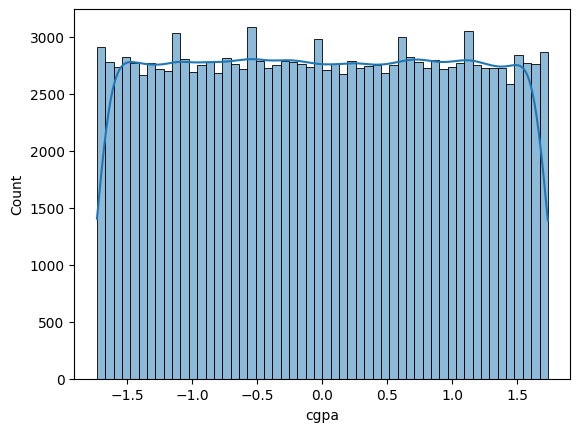

skeness is 
0.0013310578315816868
kurtosis is 
-1.1994470941617936


In [ ]:
# Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and kurtosis. 
sns.histplot(df['cgpa'], kde=True)
plt.show()
print("skeness is ")
print(df['cgpa'].skew())
print("kurtosis is ")
print(df['cgpa'].kurt())

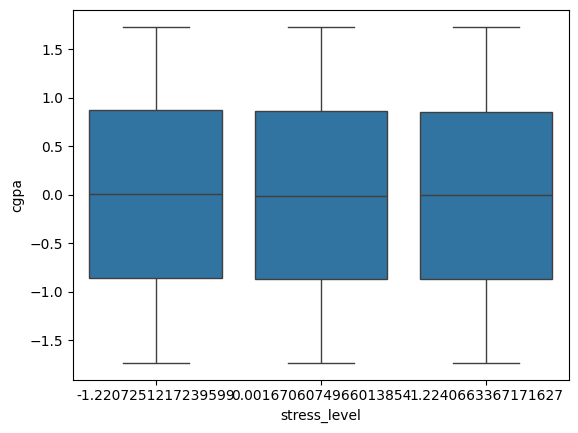

In [ ]:
# Plot a boxplot of cgpa by stress_level. What insights can you derive about the relationship between stress and academic performance? 

sns.boxplot(x='stress_level', y='cgpa', data=df)
plt.show()

C:\Users\AC\AppData\Local\Temp\ipykernel_4152\2004115428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender_Male', y='anxiety_score', data=df, palette='Set1')


C:\Users\AC\AppData\Local\Temp\ipykernel_4152\2004115428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender_Male', y='anxiety_score', data=df, palette='Set1')


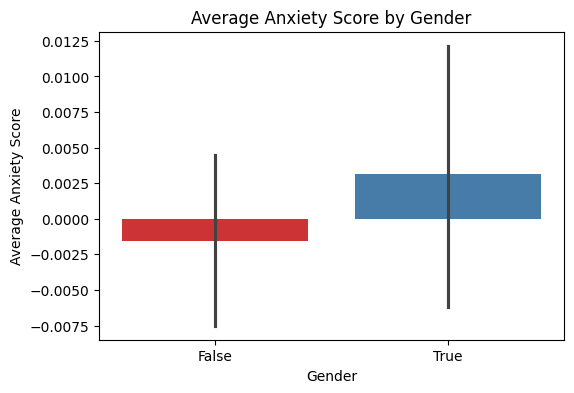

In [ ]:
# Create a bar plot showing average anxiety_score by gender. Which gender shows higher anxiety, and does this align with common expectations?
plt.figure(figsize=(6,4))
sns.barplot(x='gender_Male', y='anxiety_score', data=df, palette='Set1')
plt.title("Average Anxiety Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Anxiety Score")
plt.show()


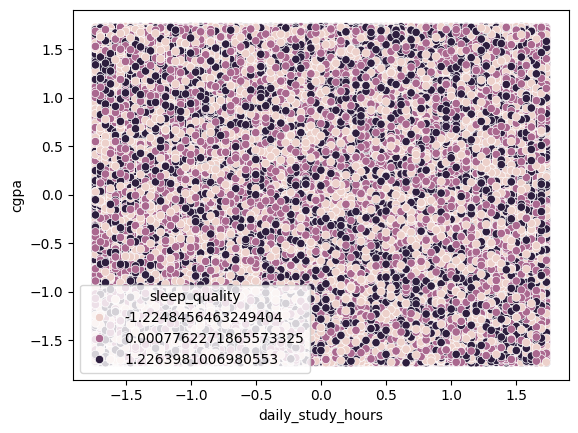

In [ ]:
# Plot a scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by sleep_quality. What patterns emerge?


sns.scatterplot(x='daily_study_hours', y='cgpa', hue='sleep_quality', data=df)
plt.show()

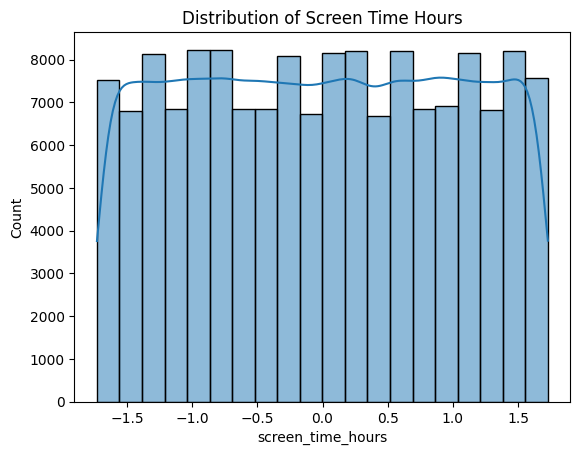

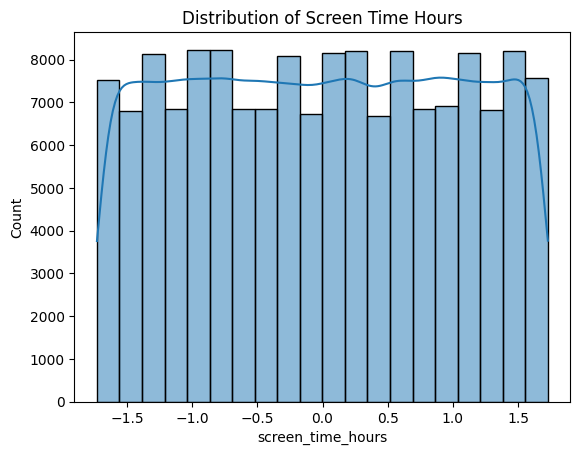

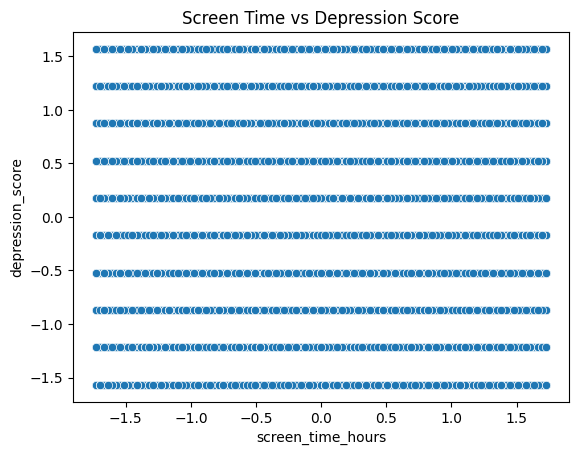

In [ ]:
# Plot the distribution of screen_time_hours. Identify any extreme values and relate them to depression_score. 

sns.histplot(df['screen_time_hours'], kde=True, bins=20)
plt.title("Distribution of Screen Time Hours")
plt.show()

# in this step we plot the scatter chart to detect the outliers
# Relationship
sns.scatterplot(x='screen_time_hours', y='depression_score', data=df)
plt.title("Screen Time vs Depression Score")
plt.show()

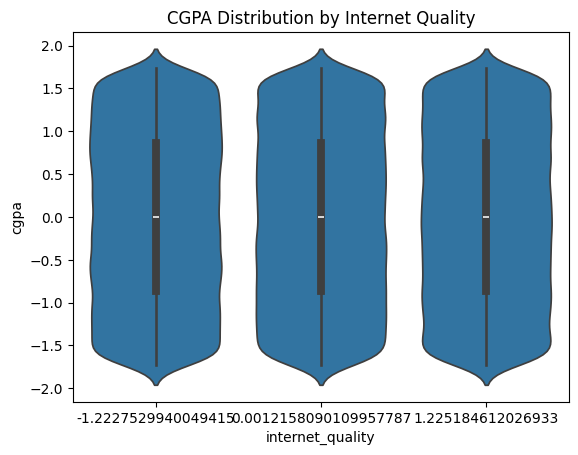

In [ ]:
# Create a violin plot of cgpa by internet_quality. What does this suggest about internet quality's impact on academics? 

# plt.figure(figsize=(8,5))
sns.violinplot(x='internet_quality', y='cgpa', data=df)
plt.title("CGPA Distribution by Internet Quality")
plt.show()


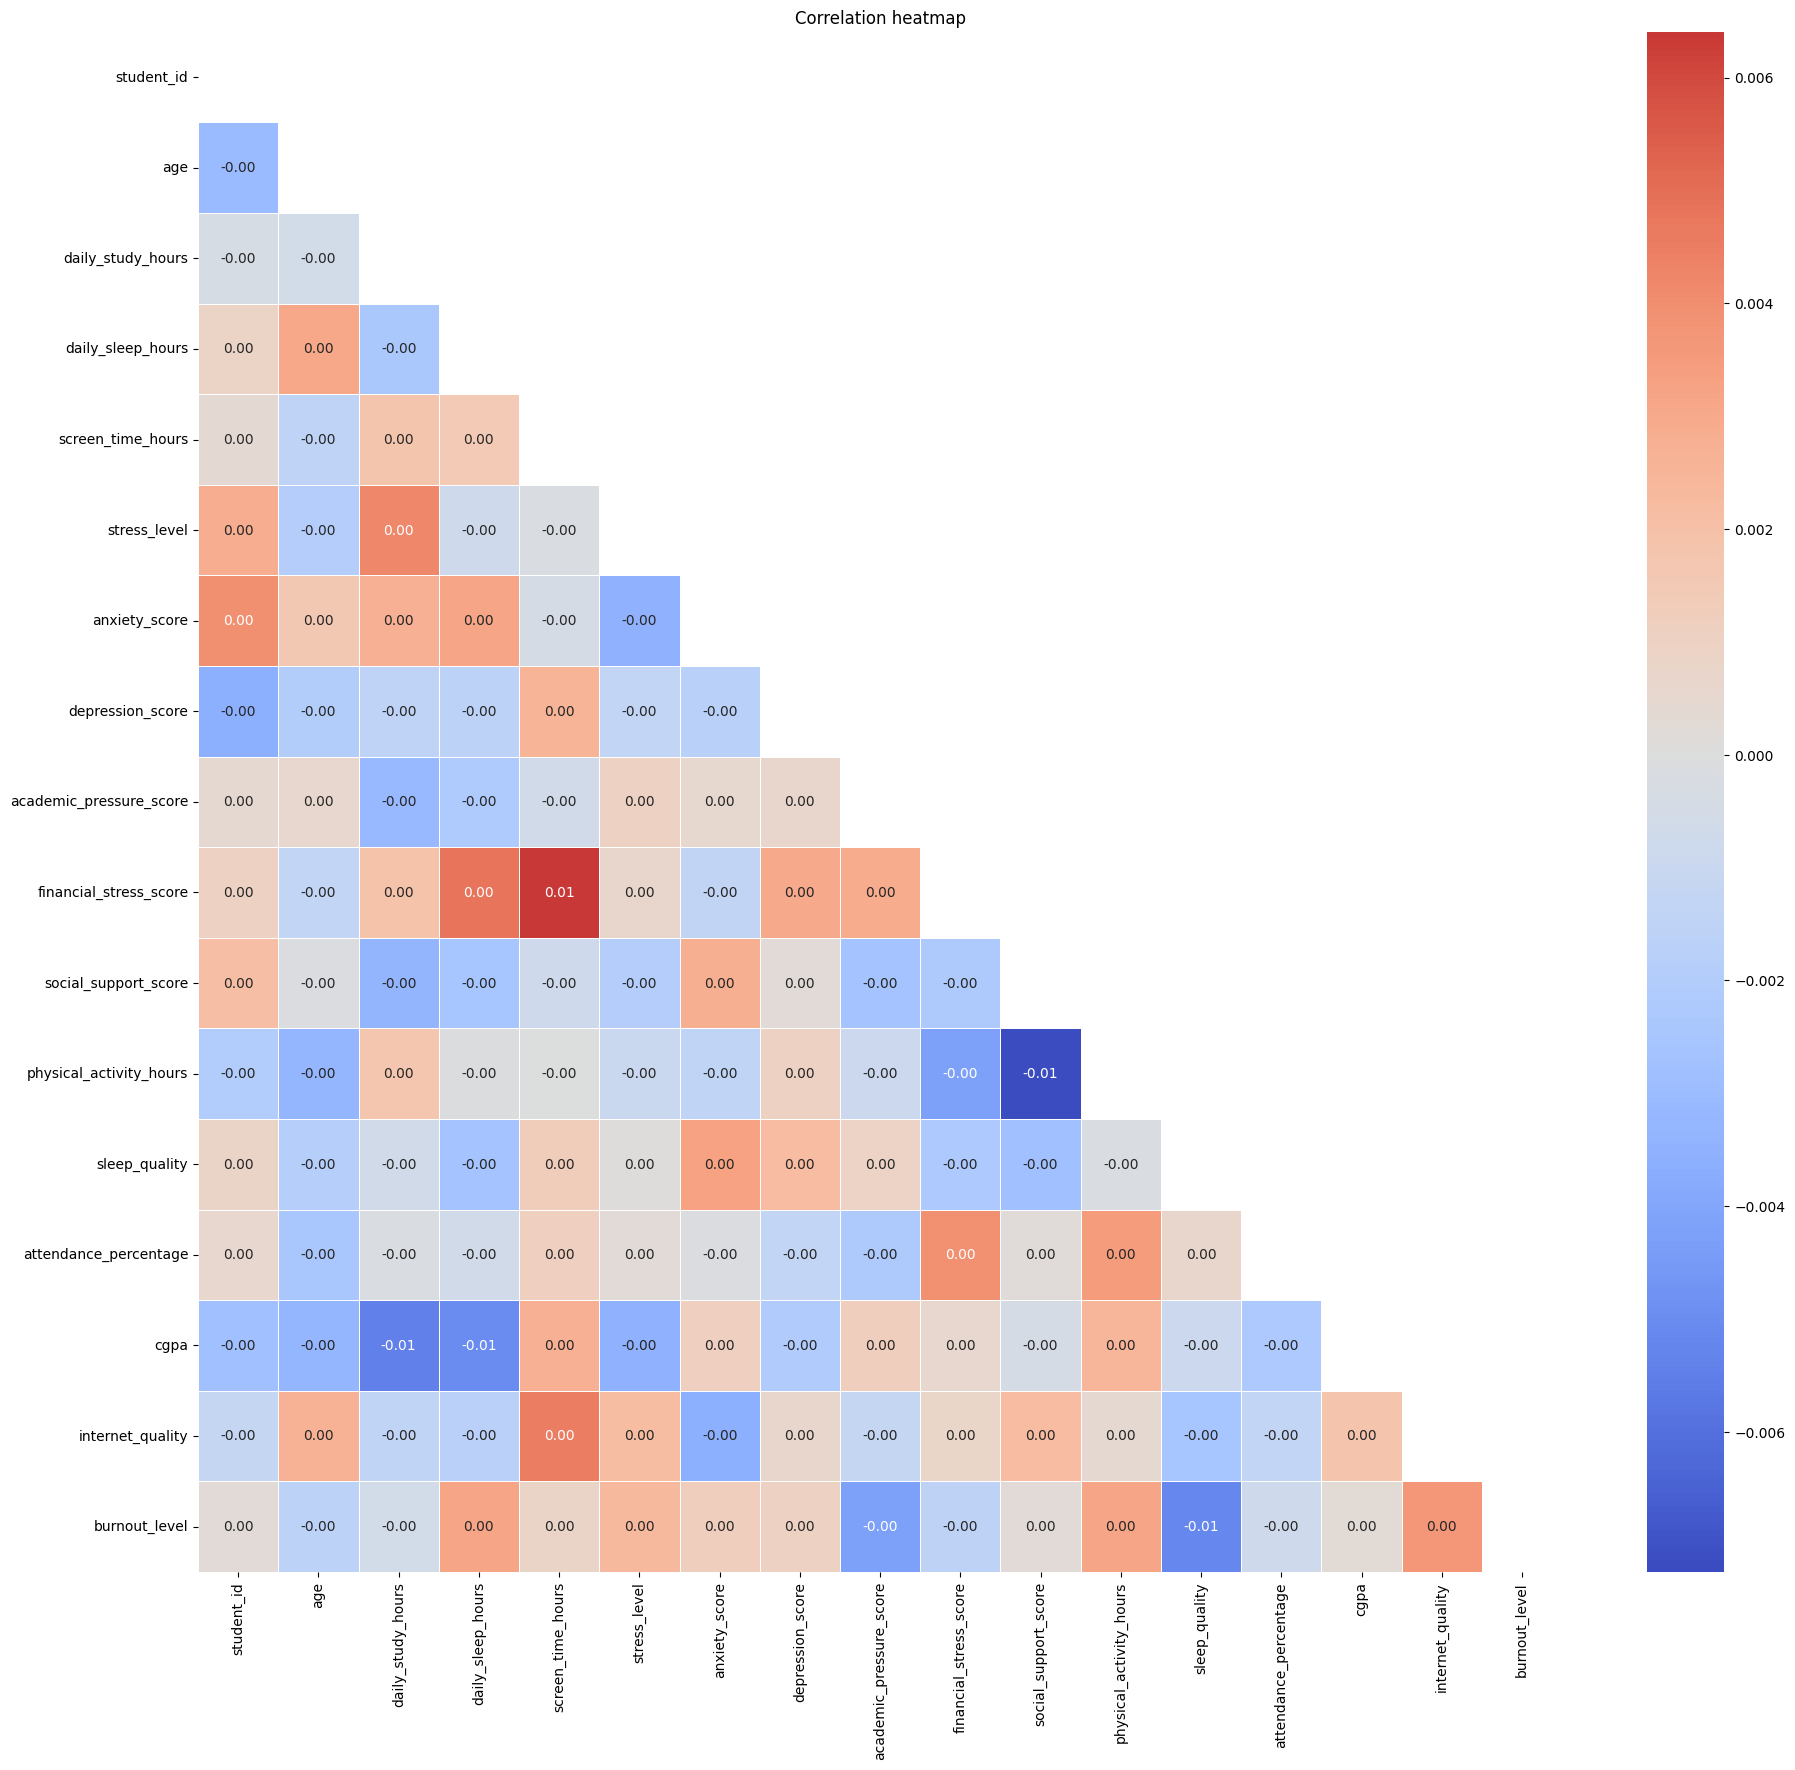

In [ ]:
# Plot a heatmap of the correlation matrix for all numerical variables. Which features are most correlated with cgpa? With anxiety_score? 

# num_df = df.select_dtypes(include=["number"])
# corr = num_df.corr()

# optional: mask upper triangle for readability
# mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(22,20))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("Correlation heatmap")
plt.show()

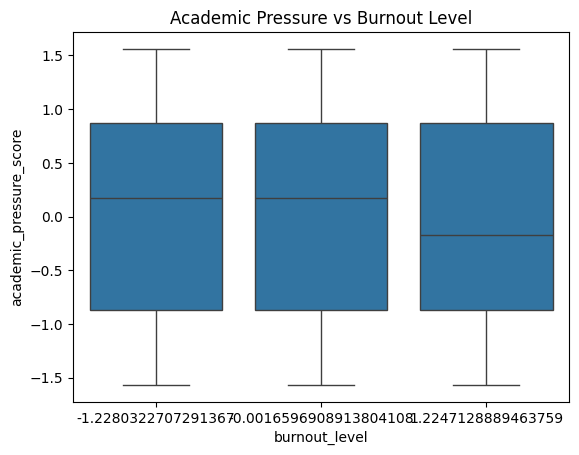

In [ ]:
#  Boxplot of academic_pressure_score by burnout_level. Is there a statistically significant difference visible? 

sns.boxplot(x='burnout_level', y='academic_pressure_score', data=df)

plt.title("Academic Pressure vs Burnout Level")
plt.show()


In [ ]:
X=df[['daily_study_hours','screen_time_hours','anxiety_score']]
y=df['burnout_level']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)
X_train

,daily_study_hours,screen_time_hours,anxiety_score
104025,0.536346,1.477594,-0.868171
5415,-1.120314,-1.038970,1.568648
75612,1.499521,1.320309,-0.171937
138169,0.382238,-0.063801,1.568648
87184,-1.428530,1.697794,-0.171937
...,...,...,...
119879,-0.465355,-1.322083,1.568648
103694,0.343711,-1.447911,0.872414
131932,-1.120314,-0.944598,-0.520054
146867,0.420765,1.603423,0.176180


In [ ]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [ ]:
scaler = StandardScaler()
X_poly_scaled= scaler.fit_transform(X_poly)

# Model Building — Binary Classification 
## Section 4

In [ ]:
# Target Variable Creation 

df['high_burnout'] = df['burnout_level'].apply(lambda x: 1 if x == "High" else 0)

# Feature Selection 

X = df.drop('high_burnout', axis=1)
y = df['high_burnout']

# Train-Test Split 

train_test_split(X, y, test_size=0.2)

[        student_id       age year  daily_study_hours  daily_sleep_hours  \
 129815    1.265910  0.774684  2nd           0.189603          -1.038444   
 91426     0.379354 -1.549809  2nd          -0.966206           0.069701   
 41736    -0.768188  1.549515  2nd          -1.505584           1.593401   
 78129     0.072273  1.162099  3rd          -1.158841           1.039328   
 14572    -1.395513  1.162099  4th           1.499521          -1.107703   
 ...            ...       ...  ...                ...                ...   
 88529     0.312450 -1.549809  1st           1.653629           0.554515   
 25729    -1.137853 -1.549809  2nd           0.844562           0.069701   
 58573    -0.379354  0.774684  3rd          -1.621165          -0.484371   
 24464    -1.167067 -0.000147  3rd          -1.544111           1.731919   
 149674    1.724534 -1.549809  2nd           0.574873          -0.276594   
 
         screen_time_hours  stress_level  anxiety_score  depression_score  \
 129815  

#  Model Evaluation 
## Section 5

In [ ]:
# Predict on test data
y_pred = df.predict(X_test)

# Calculate metrics
accuracy = (y_test, y_pred)
precision = (y_test, y_pred)
recall = (y_test, y_pred)
f1 = (y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

AttributeError: 'DataFrame' object has no attribute 'predict'